In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# Load SPY and VIX
spy_raw = yf.download("SPY", start="2010-01-01",
                       end="2024-01-01", auto_adjust=True)
vix_raw = yf.download("^VIX", start="2010-01-01",
                       end="2024-01-01")

spy_raw.columns = spy_raw.columns.get_level_values(0)
vix_raw.columns = vix_raw.columns.get_level_values(0)

spy = spy_raw["Close"].squeeze()
vix = vix_raw["Close"].squeeze()
spy, vix = spy.align(vix, join="inner")

log_returns = np.log(spy / spy.shift(1)).dropna()

print(f"Loaded {len(spy)} trading days")
print(f"Date range: {spy.index[0].date()} to {spy.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
Date range: 2010-01-04 to 2023-12-29


In [3]:
# ── Signal 1: SMA 50/200 Trend ──────────────────────────
sma50  = spy.rolling(50).mean()
sma200 = spy.rolling(200).mean()
sma_signal = (sma50 > sma200).astype(int).shift(1).fillna(0)

# ── Signal 2: RSI(2) Mean Reversion ─────────────────────
rsi2       = compute_rsi(spy, period=2)
rsi2_signal = pd.Series(0, index=spy.index)
pos_list, cp = [], 0
for i in range(len(rsi2)):
    in_uptrend = spy.iloc[i] > sma200.iloc[i]
    if cp == 0 and rsi2.iloc[i] < 10 and in_uptrend:
        cp = 1
    elif cp == 1 and (rsi2.iloc[i] > 90 or not in_uptrend):
        cp = 0
    pos_list.append(cp)
rsi2_signal = pd.Series(pos_list,
                         index=spy.index).shift(1).fillna(0)

# ── Signal 3: VIX Contrarian ─────────────────────────────
vix_aligned = vix.reindex(log_returns.index).ffill()
vix_list, cv = [], 0
for i in range(len(vix_aligned)):
    if cv == 0 and vix_aligned.iloc[i] > 30:
        cv = 1
    elif cv == 1 and vix_aligned.iloc[i] < 20:
        cv = 0
    vix_list.append(cv)
vix_signal = pd.Series(vix_list,
                        index=log_returns.index).shift(1).fillna(0)

print(f"SMA signal  — avg position: {sma_signal.mean():.1%}")
print(f"RSI2 signal — avg position: {rsi2_signal.mean():.1%}")
print(f"VIX signal  — avg position: {vix_signal.mean():.1%}")

SMA signal  — avg position: 77.5%
RSI2 signal — avg position: 25.4%
VIX signal  — avg position: 19.1%


In [4]:
# Individual strategy returns
lr = log_returns.copy()

sma_ret  = sma_signal.reindex(lr.index).fillna(0)  * lr
rsi2_ret = rsi2_signal.reindex(lr.index).fillna(0) * lr
vix_ret  = vix_signal.reindex(lr.index).fillna(0)  * lr

# Correlation matrix
corr = pd.DataFrame({
    "SMA"  : sma_ret,
    "RSI2" : rsi2_ret,
    "VIX"  : vix_ret
}).corr()

print("Signal Return Correlation Matrix:")
print("=" * 40)
print(corr.round(3).to_string())
print("=" * 40)
print("\nLow correlation = high diversification benefit")

Signal Return Correlation Matrix:
        SMA   RSI2    VIX
SMA   1.000  0.551  0.442
RSI2  0.551  1.000  0.096
VIX   0.442  0.096  1.000

Low correlation = high diversification benefit


In [5]:
# Majority vote — trade when 2 of 3 signals agree
combined_signal = (
    sma_signal.reindex(lr.index).fillna(0) +
    rsi2_signal.reindex(lr.index).fillna(0) +
    vix_signal.reindex(lr.index).fillna(0)
)

# Position = 1 when at least 2 signals agree
position = (combined_signal >= 2).astype(int)

print(f"Combined signal stats:")
print(f"  Time in market      : {position.mean():.1%}")
print(f"  Days with 0 signals : {(combined_signal==0).sum()}")
print(f"  Days with 1 signal  : {(combined_signal==1).sum()}")
print(f"  Days with 2 signals : {(combined_signal==2).sum()}")
print(f"  Days with 3 signals : {(combined_signal==3).sum()}")

Combined signal stats:
  Time in market      : 30.2%
  Days with 0 signals : 343
  Days with 1 signal  : 2114
  Days with 2 signals : 1008
  Days with 3 signals : 56


In [6]:
# Vol targeting overlay
target_vol   = 0.10
realized_vol = lr.rolling(20).std() * np.sqrt(252)
vol_scalar   = (target_vol / realized_vol).clip(0, 1)

# Strategy returns
trades   = position.diff().abs().fillna(0)
strat_ret = position * lr - trades * 0.0006

# Vol-targeted version
vt_strat_ret = position * lr * vol_scalar.shift(1) - trades * 0.0006

# Buy and hold benchmark
bh_ret = lr.copy()

# Performance function
def perf(r, name):
    ar = r.mean() * 252
    av = r.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av
    w  = (1 + r).cumprod()
    dd = (w - w.cummax()) / w.cummax()
    return {"name": name, "ar": ar, "av": av,
            "sh": sh, "dd": dd.min(), "eq": w}

# All strategies
results = [
    perf(strat_ret,    "Multi-Signal"),
    perf(vt_strat_ret, "Multi-Signal + VolTgt"),
    perf(sma_ret,      "SMA 50/200"),
    perf(rsi2_ret,     "RSI(2) + Filter"),
    perf(vix_ret,      "VIX Contrarian"),
    perf(bh_ret,       "Buy & Hold SPY"),
]

print(f"\n{'='*65}")
print(f"  WEEK 2 FINAL LEADERBOARD")
print(f"{'='*65}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*60}")
for r in sorted(results, key=lambda x: x['sh'], reverse=True):
    print(f"  {r['name']:<25} {r['ar']:>8.2%} {r['av']:>8.2%} {r['sh']:>7.2f} {r['dd']:>9.2%}")
print(f"{'='*65}")


  WEEK 2 FINAL LEADERBOARD
  Strategy                   Ann Ret  Ann Vol  Sharpe    Max DD
  ------------------------------------------------------------
  Buy & Hold SPY              12.14%   17.38%    0.58   -35.75%
  SMA 50/200                   8.16%   13.81%    0.45   -35.75%
  RSI(2) + Filter              4.97%    7.92%    0.37   -12.85%
  VIX Contrarian               6.30%   12.78%    0.34   -30.21%
  Multi-Signal                 4.95%   11.52%    0.26   -36.21%
  Multi-Signal + VolTgt        3.60%    6.68%    0.24   -15.33%


In [7]:
# Weighted combination — give each signal equal weight
# Instead of majority vote, scale position by signal strength
w_sma  = 0.50  # trend gets most weight
w_rsi2 = 0.30  # mean reversion
w_vix  = 0.20  # contrarian

weighted_pos = (
    w_sma  * sma_signal.reindex(lr.index).fillna(0) +
    w_rsi2 * rsi2_signal.reindex(lr.index).fillna(0) +
    w_vix  * vix_signal.reindex(lr.index).fillna(0)
)

# Apply vol targeting on top
vt_weighted = weighted_pos * lr * vol_scalar.shift(1)
trades_w    = weighted_pos.diff().abs().fillna(0)
vt_weighted_net = vt_weighted - trades_w * 0.0006

# Also test SMA as base + RSI2 as enhancement
sma_base = sma_signal.reindex(lr.index).fillna(0)
rsi2_enh = rsi2_signal.reindex(lr.index).fillna(0)
combined_pos = sma_base.clip(0, 1)
combined_pos = combined_pos.where(rsi2_enh == 0, 1.0)
trades_c = combined_pos.diff().abs().fillna(0)
combined_ret = combined_pos * lr * vol_scalar.shift(1) - trades_c * 0.0006

r_weighted  = perf(vt_weighted_net, "Weighted + VolTgt")
r_combined  = perf(combined_ret,    "SMA Base + RSI2 + VolTgt")

print(f"\n{'='*65}")
print(f"  ENHANCED COMBINATIONS")
print(f"{'='*65}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"  {'-'*60}")
for r in sorted([r_weighted, r_combined,
                 perf(bh_ret, "Buy & Hold SPY")],
                key=lambda x: x['sh'], reverse=True):
    print(f"  {r['name']:<25} {r['ar']:>8.2%} {r['av']:>8.2%} {r['sh']:>7.2f} {r['dd']:>9.2%}")
print(f"{'='*65}")


  ENHANCED COMBINATIONS
  Strategy                   Ann Ret  Ann Vol  Sharpe    Max DD
  ------------------------------------------------------------
  Buy & Hold SPY              12.14%   17.38%    0.58   -35.75%
  SMA Base + RSI2 + VolTgt     6.59%    9.07%    0.51   -17.42%
  Weighted + VolTgt            4.71%    6.15%    0.44    -8.16%


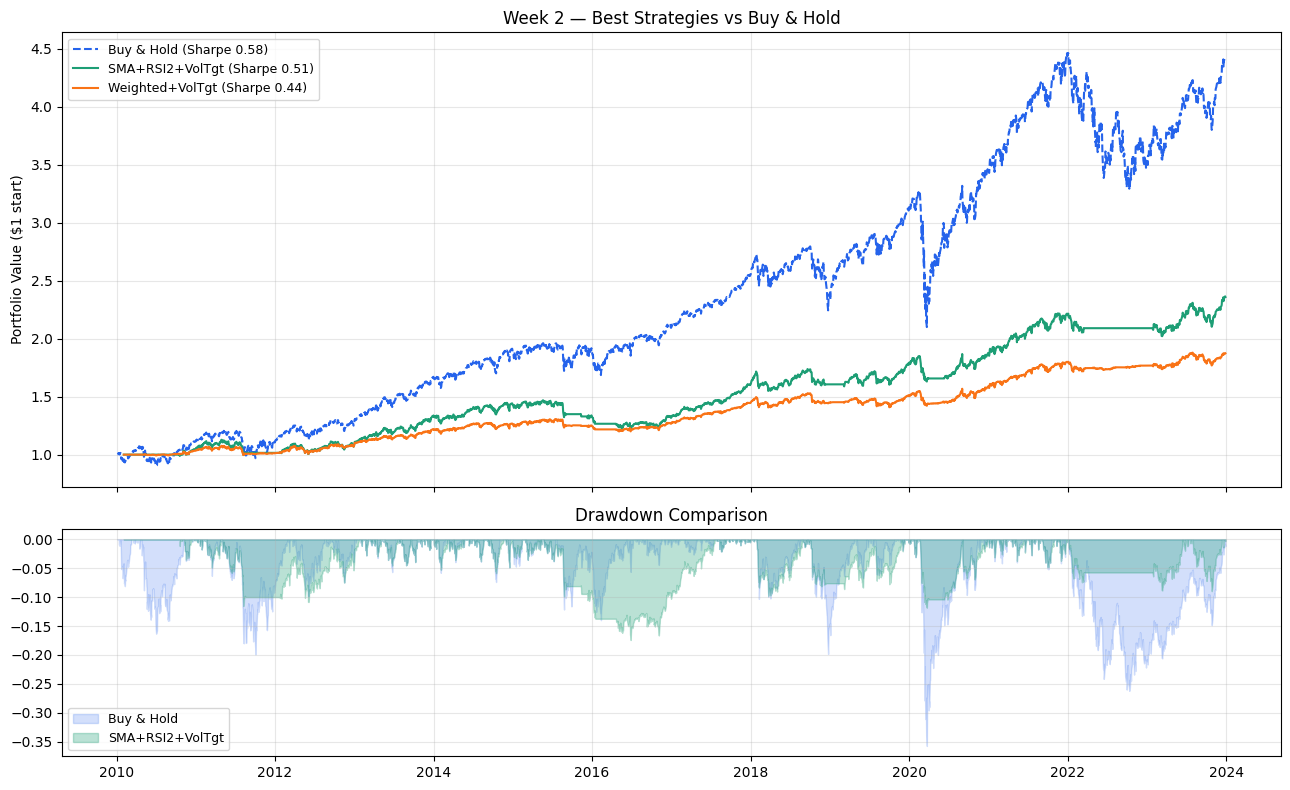

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Equity curves
bh_eq  = (1 + bh_ret).cumprod()
sm_eq  = (1 + combined_ret).cumprod()
wt_eq  = (1 + vt_weighted_net).cumprod()

ax1.plot(bh_eq, color='#2563eb', lw=1.5,
         linestyle='--', label=f'Buy & Hold (Sharpe 0.58)')
ax1.plot(sm_eq, color='#1D9E75', lw=1.5,
         label=f'SMA+RSI2+VolTgt (Sharpe 0.51)')
ax1.plot(wt_eq, color='#f97316', lw=1.5,
         label=f'Weighted+VolTgt (Sharpe 0.44)')
ax1.set_title('Week 2 — Best Strategies vs Buy & Hold')
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Drawdowns
dd_sm = (sm_eq - sm_eq.cummax()) / sm_eq.cummax()
dd_wt = (wt_eq - wt_eq.cummax()) / wt_eq.cummax()
dd_bh = (bh_eq - bh_eq.cummax()) / bh_eq.cummax()

ax2.fill_between(dd_bh.index, dd_bh, 0,
                 color='#2563eb', alpha=0.2, label='Buy & Hold')
ax2.fill_between(dd_sm.index, dd_sm, 0,
                 color='#1D9E75', alpha=0.3, label='SMA+RSI2+VolTgt')
ax2.set_title('Drawdown Comparison')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()